# Posterior predictive checks and posterior structure

PPC uses new simulator seeds and compares the frozen 14D cortical-rate
summaries against prior predictive baselines. It checks predictive adequacy,
not calibration. Posterior structure then asks whether uncertainty is broad,
contracted, or organized into compensatory ridges.

In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "S4_sbi").exists() else cwd.parent.parent
SRC = PROJECT_ROOT / "S4_sbi" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
RESULTS = PROJECT_ROOT / "S4_sbi" / "results" / "figure10_8d_7d"
assert os.environ.get("CONDA_DEFAULT_ENV") == "neurolib"
print("environment:", os.environ.get("CONDA_DEFAULT_ENV"))
print("python:", sys.executable)
print("results:", RESULTS)

environment: neurolib
python: C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe
results: D:\Year3_Mao_Projects\sleep_loop\S4_sbi\results\figure10_8d_7d


## Predictive summary audit

Errors are scaled by the training-set feature IQR. This is a numerical
comparison within synthetic cortical-rate space and does not map firing rate
to microvolts.

,created_utc,track,posterior_attempted,posterior_failed,prior_attempted,prior_failed,features_posterior_better,overall_posterior_scaled_error,overall_prior_scaled_error,overall_improvement_fraction,member_counts,preregistration_hash
0,2026-07-31T11:29:29.106128+00:00,8d,256,0,256,0,14,0.330761,0.827917,0.600490,"[54, 46, 55, 51, 50]",a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...
1,2026-07-31T11:36:16.669922+00:00,7d,256,0,256,0,14,0.356353,0.875170,0.592818,"[51, 54, 38, 57, 56]",a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...


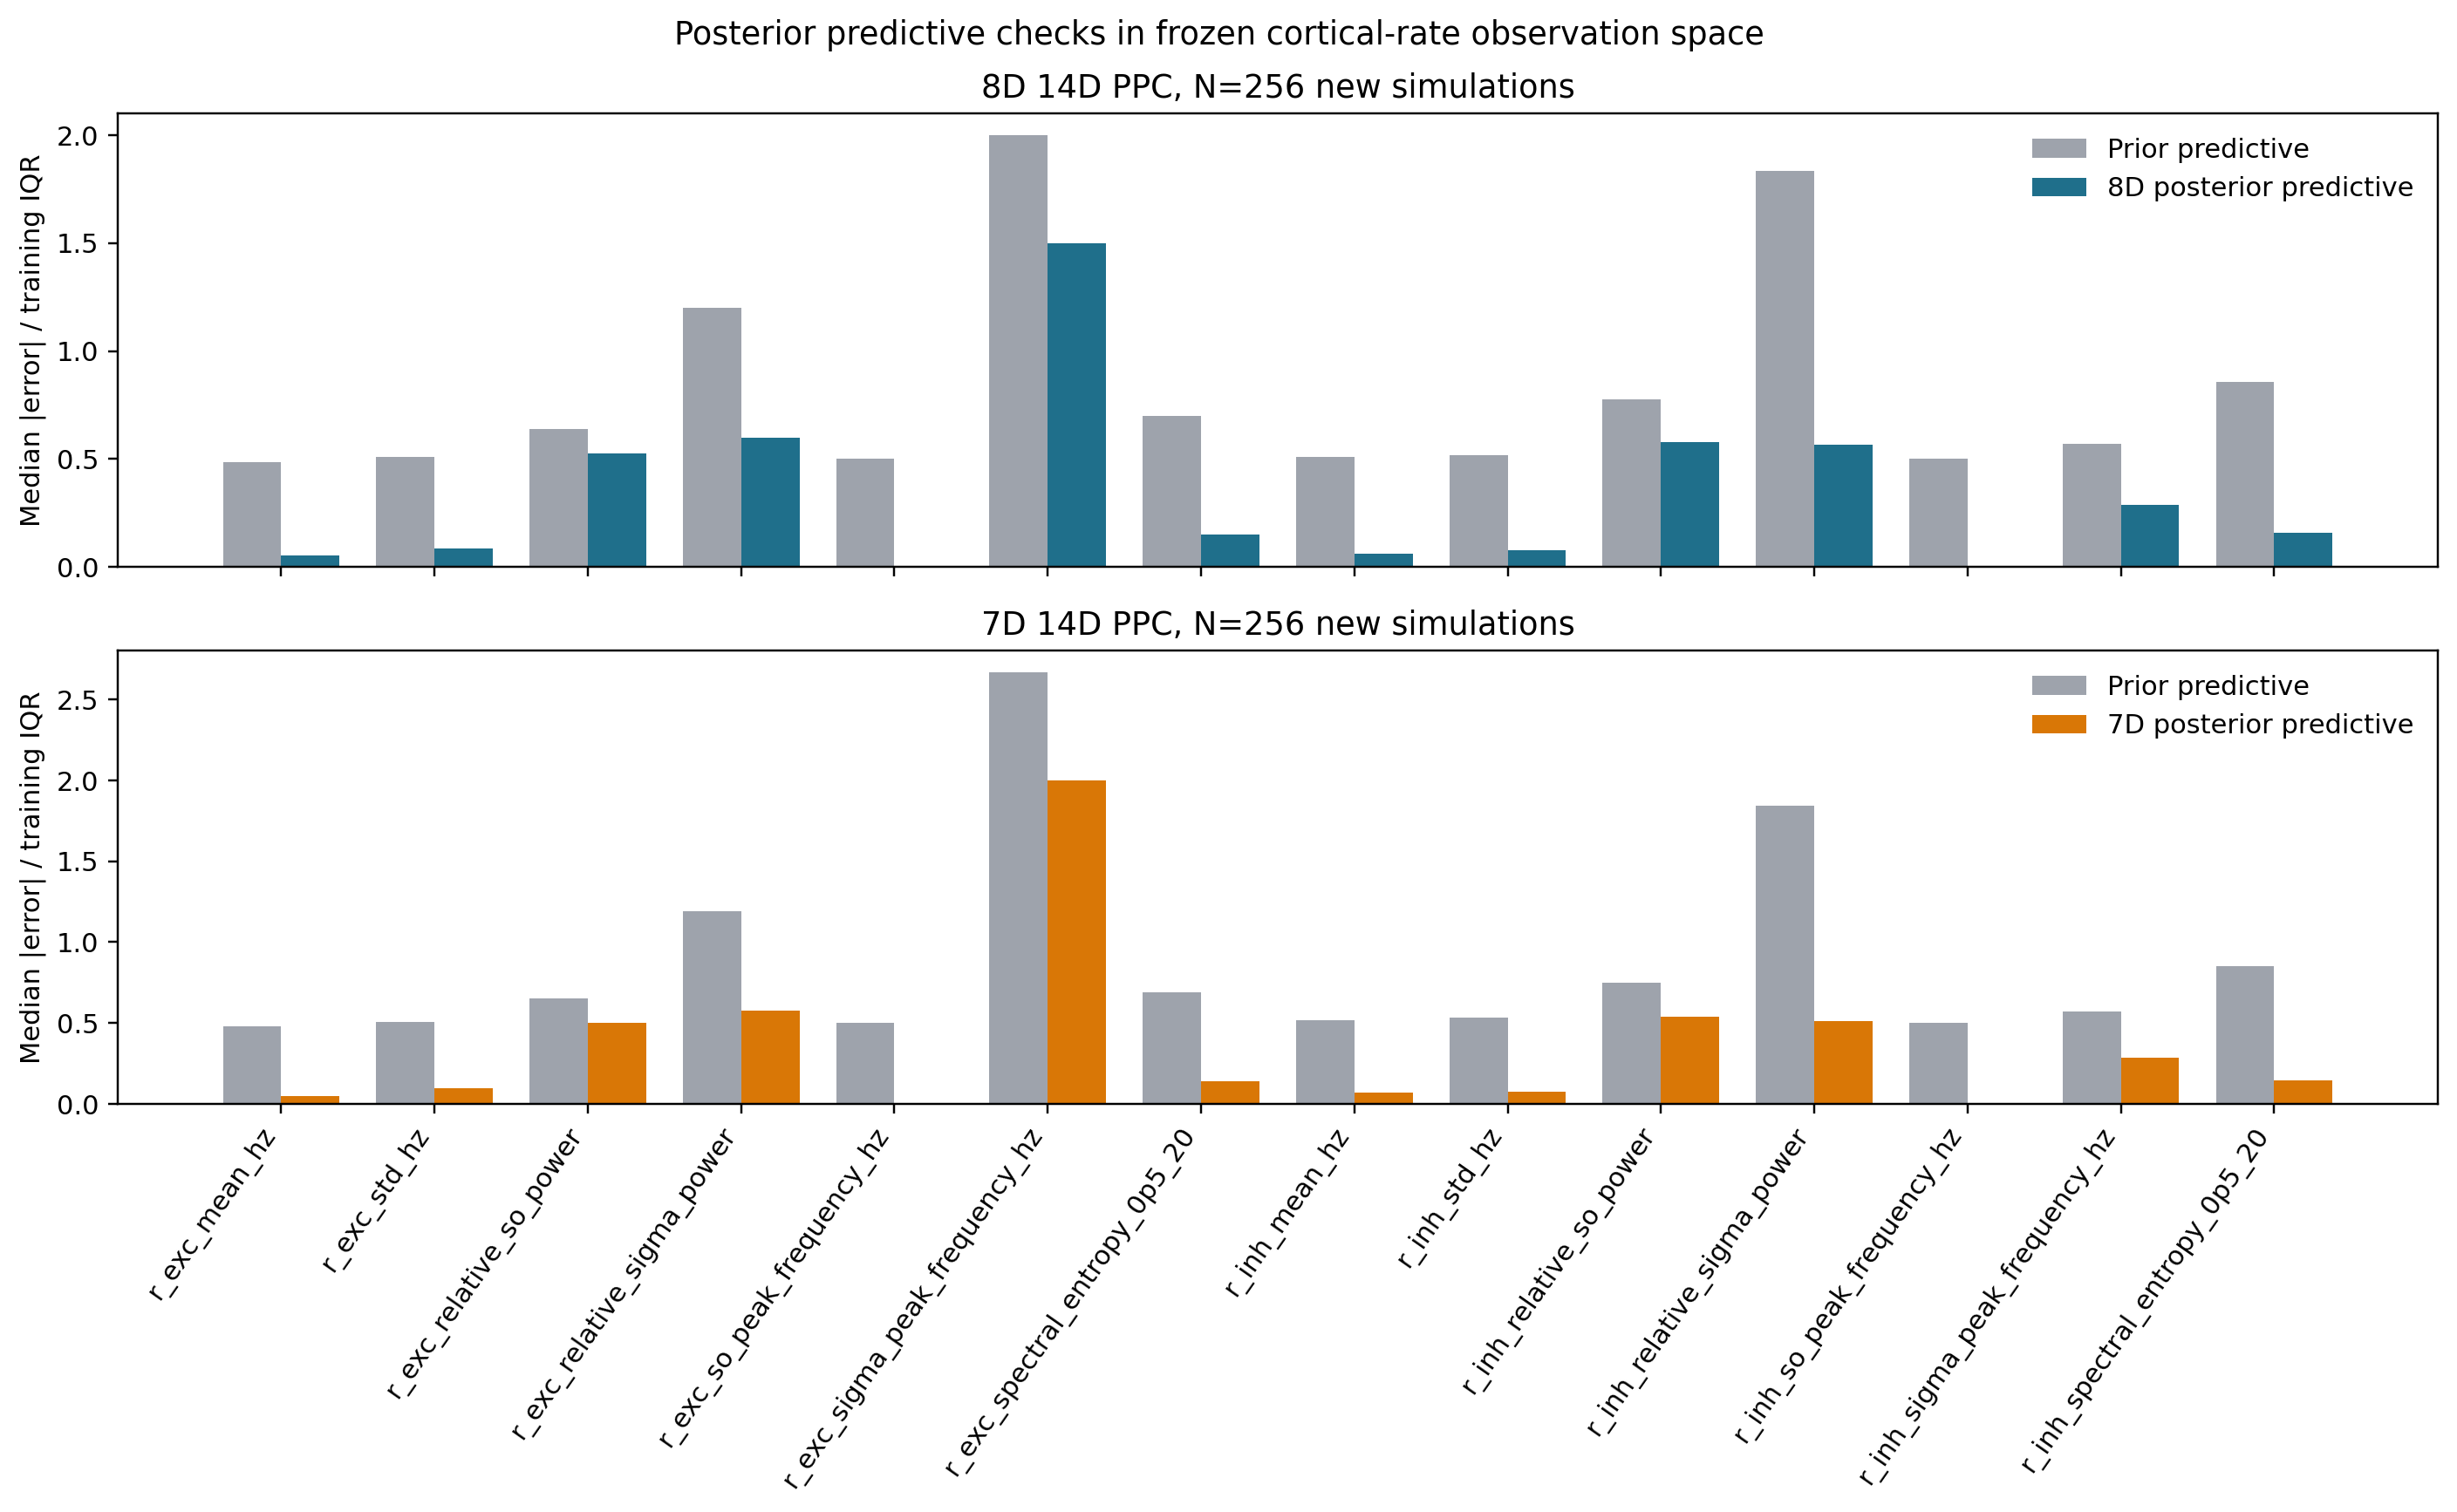

In [2]:
ppc_rows = []
for track in ("8d", "7d"):
    summary = json.loads((RESULTS / "diagnostics" / "ppc" / track / "ppc_summary.json").read_text())
    ppc_rows.append(summary)
display(pd.DataFrame(ppc_rows))
display(Image(filename=str(RESULTS / "figures" / "figure10_ppc_8d_7d.png")))

## Marginals and mandatory ridges

The dashed prior density is flat in prior-scaled coordinates. A broad
`c_ctx2th` marginal is scientifically acceptable when calibrated. The
`c_th2ctx`-`c_ctx2th` and `g_LK`-`g_h` panels expose compensatory structure;
correlation alone is not causation.

,track,samples,median_posterior_sd_over_prior_sd,least_contracted_parameter,least_contracted_ratio,most_contracted_parameter,most_contracted_ratio,strongest_pair,c_th2ctx_c_ctx2th_correlation,g_LK_g_h_correlation,preregistration_hash
0,8d,50000,0.659553,c_ctx2th,1.006194,mui,0.142028,"{'parameter_a': 'mue', 'parameter_b': 'tauA', ...",0.03091,-0.02983,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...
1,7d,50000,0.624543,tauA,0.877851,mui,0.120964,"{'parameter_a': 'mue', 'parameter_b': 'tauA', ...",NaN,-0.07857,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...


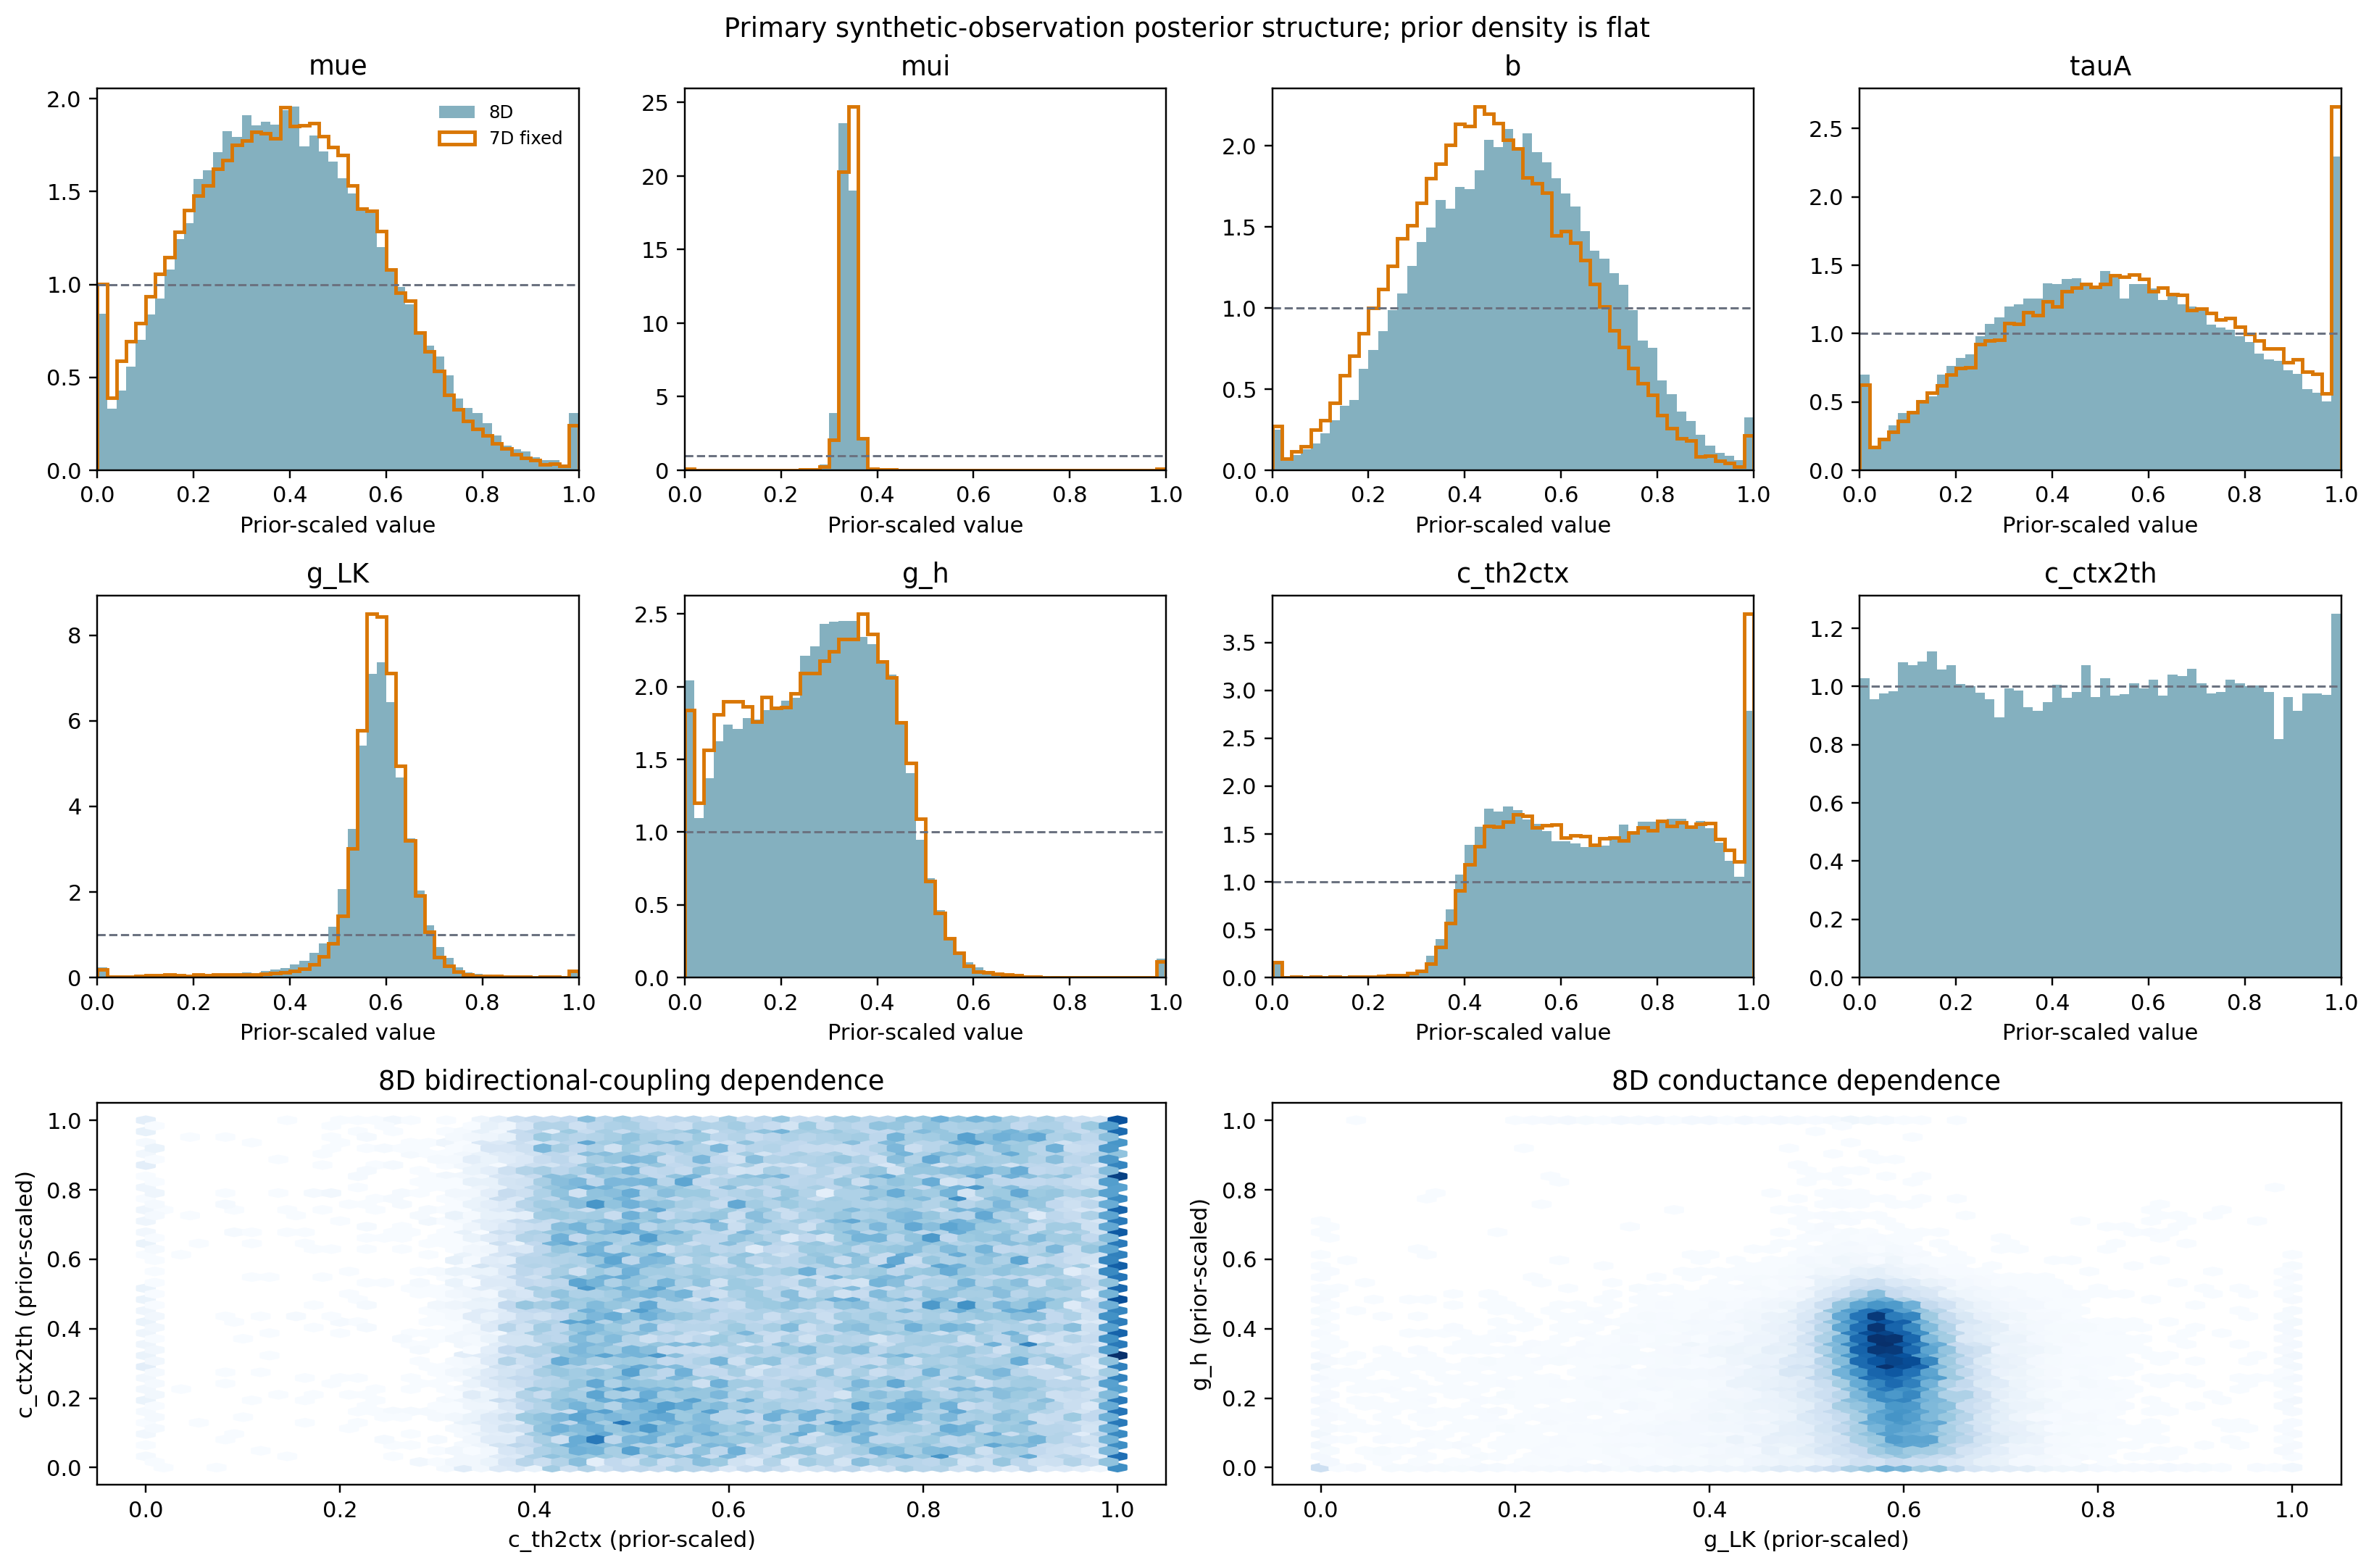

In [3]:
structure = []
for track in ("8d", "7d"):
    payload = json.loads((RESULTS / "diagnostics" / "posterior_structure" / track / "posterior_structure_summary.json").read_text())
    structure.append(payload)
display(pd.DataFrame(structure))
display(Image(filename=str(RESULTS / "figures" / "figure10_posterior_structure_identifiability.png")))